# Preprocess imaging data

## Import libraries

In [18]:
from pathlib import Path
import os.path
from datetime import datetime
import pickle
import matplotlib.pyplot as plt
import numpy as np
import warnings

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis
from unityvr.viz import viz, utils
from gulp2p.preproc import utils as utils
from gulp2p.preproc import ImagingPreProc as iPP
from gulp2p.preproc import ROIs as ROIs

## Get file names for a given set of experiments

In [19]:
file_names = utils.loadFileNames()

In [20]:
print(file_names)

('Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00001.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00002.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00003.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00004.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00005.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00006.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00007.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00008.tif', 'Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly1_00009.tif')


## Preprocess data

### Functions:

In [21]:
def get_bhv_path(trial_tiff_path, bhv_data_folder, max_creation_delay=360, min_file_mb=2.5, creation_offset=0, filter_date='20231201'):
    # Given the path to a trials tiff file (trial_tiff_path)
    # Find the corresponding behavioral data file in the bhv_data_folder

    # Get creation date of tiff file using os.path.getctime(path)
    # Convert to datetime object
    # For json file in bhv_data_folder
    #   get datetime of date in json filename
    #   get the difference between tiff time and json time
    # print the min time 

    tiff_unix_time = min(os.path.getctime(trial_tiff_path), os.path.getmtime(trial_tiff_path))

    if tiff_unix_time < datetime.strptime(filter_date, '%Y%m%d').timestamp():
                # print(datetime.fromtimestamp(tiff_unix_time))
                creation_offset += 360

    # print(trial_tiff_path.name)
    # print(tiff_date_time)
    # print()

    min_diff = None
    min_diff_path = None
    
    for bhv_path in bhv_data_folder.rglob('*'):
        if bhv_path.is_file() and (bhv_path.suffix == '.json'):
            # Log_2023-11-29_13-45-03.json
            date_str = "_".join(bhv_path.stem.split('_')[1:])
            date_fmt = '%Y-%m-%d_%H-%M-%S'
            bhv_date_time = datetime.strptime(date_str, date_fmt).timestamp()

            diff = bhv_date_time - tiff_unix_time + creation_offset
            abs_diff = abs(diff)
            
            file_mb = bhv_path.stat().st_size / (2**20)
            if file_mb < min_file_mb:
                # print(f"{bhv_path} is {file_mb} MB, which is smaller than min file size of {min_file_mb} MB")
                continue

            if min_diff is None:
                min_diff = abs_diff
                min_diff_path = bhv_path
            
            if abs_diff < min_diff:
                min_diff = abs_diff
                min_diff_path = bhv_path

    # Pick smallest positive date as behavioral data as long as it is smaller than the creation delay.
    if min_diff > max_creation_delay:
        warnings.warn((f"Closest behavioral file\n"
                       f"{min_diff_path}\n"
                       f"is {diff} seconds from the creation of the tiff file.\n"
                       f"This is above the max delay of {max_creation_delay}."),
                       stacklevel=2)
        return None

    print(min_diff)
    return min_diff_path



trial_tiff_path = Path(r'z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly2_00001.tif')
bhv_data_folder = Path(r'Z:\FlyVR\FlyVR data\Kerstin\20231129')
bhv_path = get_bhv_path(trial_tiff_path, bhv_data_folder)

3.437638282775879


In [22]:
bhv_data_folder = Path(r'Z:\FlyVR\FlyVR data\Kerstin')
img_data_folder = Path(r"Z:\2PImaging\Kerstin\MIMS\20231129")
trial_tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231204\20231204_DR019xEF024_Fly1_00001.tif")

for file in img_data_folder.rglob('*'):
    if file.is_file() and (file.suffix == ".tif"):
        bhv_path = get_bhv_path(file, bhv_data_folder,
                                max_creation_delay=720, min_file_mb=5)
        print(file)
        print(bhv_path)
        print()

326.45198488235474
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00001.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_13-45-03.json

18.293753623962402
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00002.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_13-46-48.json

1.2559854984283447
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00003.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_13-58-02.json

3.609776020050049
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00004.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_14-04-48.json

4.1608099937438965
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00005.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_14-11-22.json

3.5261480808258057
Z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly1_00006.tif
Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_14-18-26.json

3.330331563949585
Z:\2PImaging\Kerstin\MI

In [23]:
bhv_path = Path(r"Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_13-45-03.json")
uvr = lp.constructUnityVRexperiment(str(bhv_path.parent), bhv_path.name)

length = uvr.posDf.iloc[-1]['time']
print(f"trial took {length:.3f} seconds to run ({length//60:.0f} minutes and {length%60:.3f} seconds)")


correcting for Unity angle convention.
trial took 46.751 seconds to run (0 minutes and 46.751 seconds)


### For each tif:
1. Create motion corrected MIPs
2. Specify the ROIs
3. Calculate the DF/F

### Specify parameters for motion correction

In [24]:
numRefImg = 50 # the number of images to average for the reference image
upsampleFactor = 20 # how much to upsample the image in order to shift the image by less than one pixel
sigma = 2 # the sigma to use in Gaussian filtering

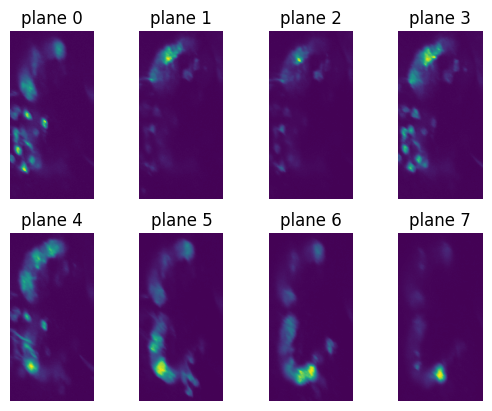

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


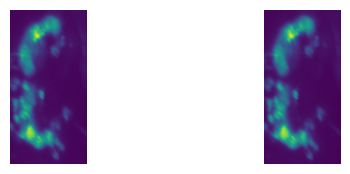

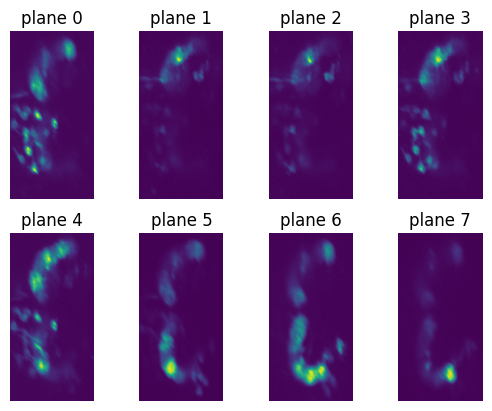

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


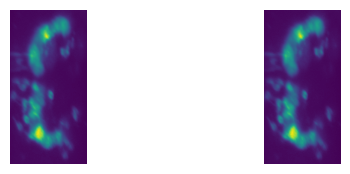

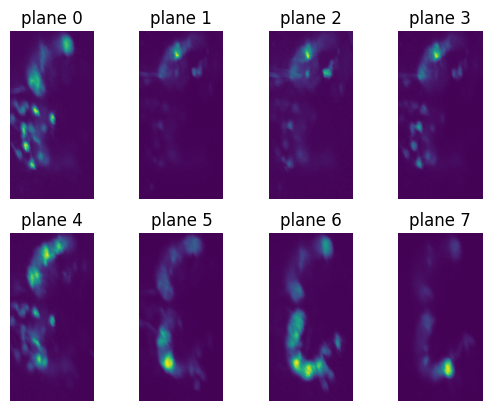

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


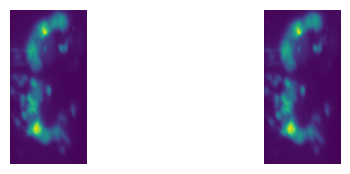

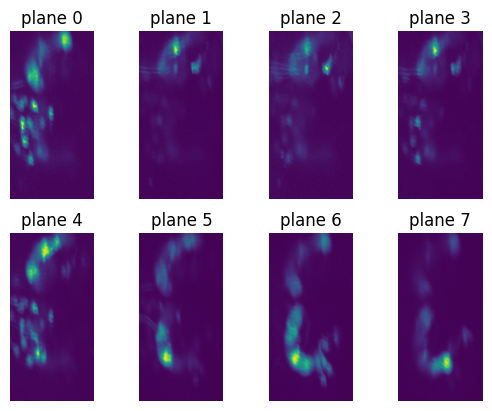

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


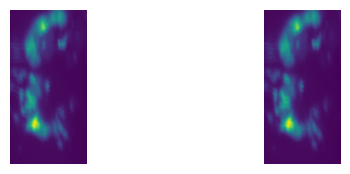

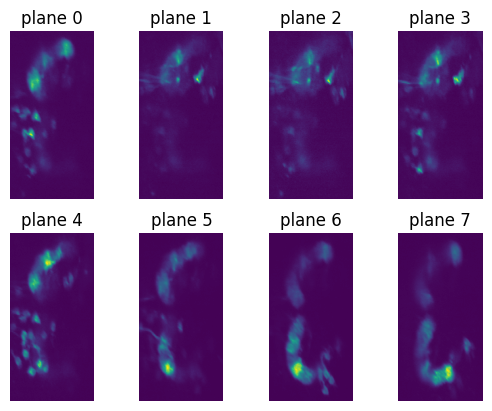

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


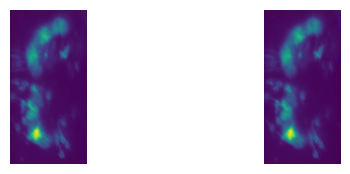

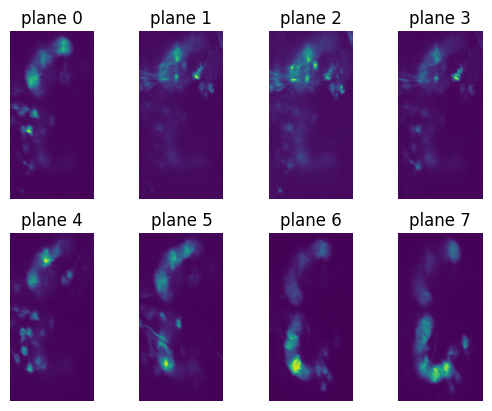

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


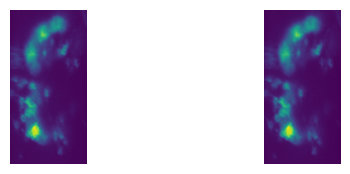

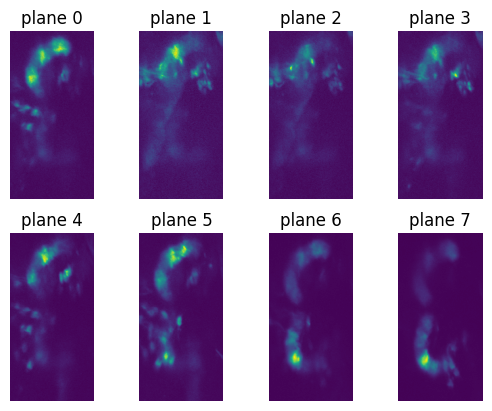

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


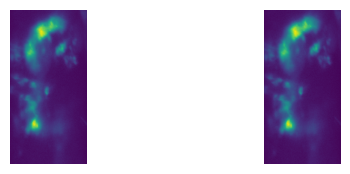

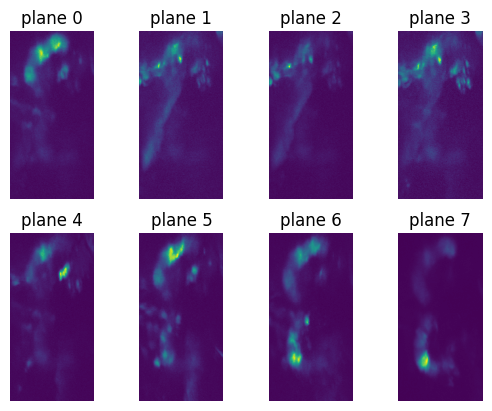

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


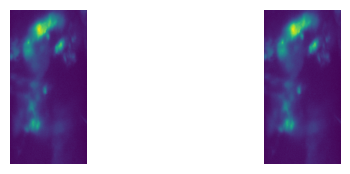

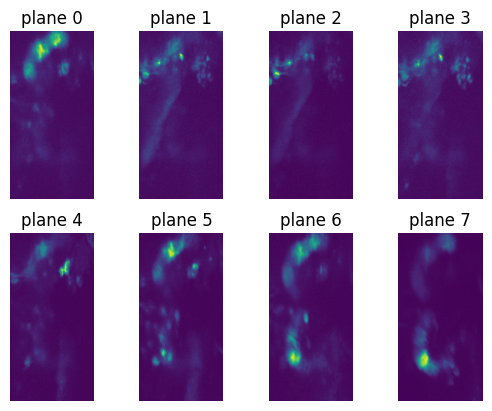

C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\ImagingPreProc.py:404: RuntimeWarning: invalid value encountered in divide
  DF[:,r] = rawF[:,r]/Fbaseline-1


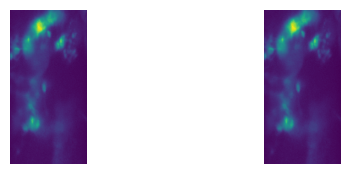

In [26]:
for i,file in enumerate(file_names):
    # Load the tif
    [stack, nCh, nDiscardFBFrames, fpv] = iPP.loadTif(file)

    # Plot the mean of each plane
    fig_mean_planes = iPP.plotMeanPlane(stack,col=0) # col=1 to plot the second channel if it exists
    
    # Specify the planes to use for the Maximum Intensity Projection (MIP)
    slices = iPP.getSlicesFromStack()
    
    # Calculate the MIP
    stack_MIP = iPP.stackToMIP(stack,slices)

    # Motion correct the MIP
    locRefImg = round(stack_MIP.shape[0]/12)# the initial position in the stack to use for the reference
    # [shift, stack_MC] = iPP.tifMotionCorrect(numRefImg, locRefImg, upsampleFactor, np.squeeze(stack_MIP[:,0,:,:]), sigma)
    
    if nCh == 1:
        [shift, stack_MC] = iPP.tifMotionCorrect(numRefImg, locRefImg, upsampleFactor, np.squeeze(stack_MIP), sigma)
    else:
        [shift, stack_MC] = iPP.tifMotionCorrect(numRefImg, locRefImg, upsampleFactor, np.squeeze(stack_MIP[:,0,:,:]), sigma)



    # Plot the before and after
    fig, axs = plt.subplots(ncols = 2, nrows = 1, figsize = (6,2))
    axs[0].imshow(stack_MIP.mean(axis=0))
    axs[0].axis('off')
    axs[1].imshow(stack_MC.mean(axis=0))
    axs[1].axis('off')
    
    # Get the ROIS - For EB wedges, there are a number of other possible ROI functions for different shapes
    if i == 0:
        [rois, allROIs, allMasks] = iPP.getROIs(stack_MC.mean(axis=0), ROIs.PolyROIs, [],'')
    else:
        [rois, allROIs, allMasks] = iPP.getROIs(stack_MC.mean(axis=0), ROIs.PolyROIs, rois, 'polygon')
    
    # Get the raw fluorescence
    rawF_G = np.zeros((stack_MC.shape[0],len(allMasks)))
    for fm_num, frame in enumerate(stack_MC):
        for r in range(0,len(allMasks)):
            rawF_G[fm_num,r] = np.multiply(frame, allMasks[r].T).sum()
    
    # Get the DF/F
    DF_G = iPP.DFoF(rawF_G)
    
    # Put all of the data into a dictionary
    exptDat = {'trialName':file.split('/')[-1][0:-4],
               'fpv': fpv,
               'meanMIP_G': np.squeeze(stack_MC.mean(axis=0)),
               'ROIOutlines': rois,
               'allROIs': allROIs,
               'rawF_G':rawF_G,
               'DF_G': DF_G
              }
    
    # Pickle and save the data
    outfile = open(file[0:-4] + '_DF.p', 'wb')
    pickle.dump(exptDat, outfile)
    outfile.close()

In [ ]:
print(nCh)

1


In [ ]:
#TZCYX
stack.shape

(1350, 7, 1, 512, 512)

In [ ]:
stack_MIP.shape

(1350, 512, 512)

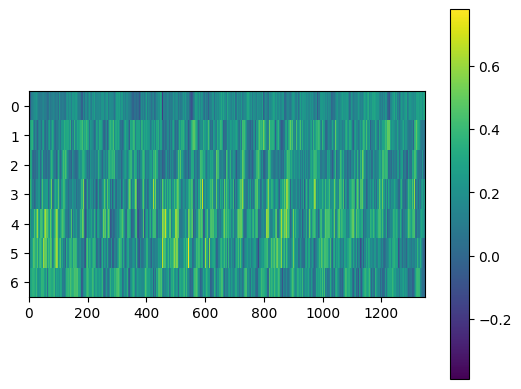

In [ ]:
fig,ax = plt.subplots()
act = ax.imshow(DF_G.T, aspect = 100, interpolation="none")
fig.colorbar(act)
# plt.savefig(fig, dpi = 300, format ='svg')

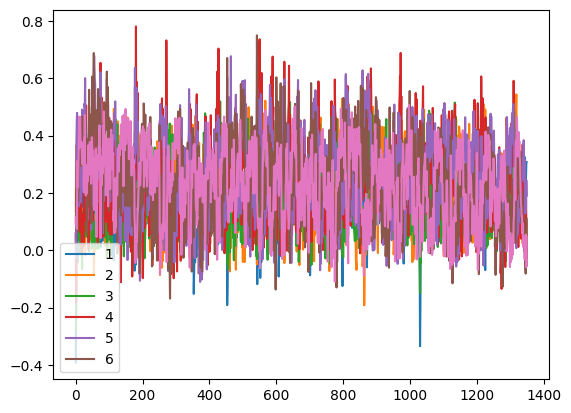

In [ ]:
fig,ax = plt.subplots()
ax.plot(np.arange(0,len(DF_G)),DF_G)
ax.legend(labels = '123456')
